# Previsão de demanda semanal por tipo de café

**Problema:** A máquina é reabastecida em rota fixa, sem visibilidade de demanda por produto. Isso
gera dois problemas: ruptura (produto esgotado, venda perdida) e excesso (capital
parado e visitas que não precisavam acontecer).

**Solução.** Previsão semanal de demanda por tipo de café, convertida em uma quantidade de
reposição.

---
## 1. Ingestão

Fonte única, direto do Kaggle (`ihelon/coffee-sales`).

In [1]:
import warnings; warnings.simplefilter("ignore")
import logging
logging.disable(logging.INFO)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.ensemble import ExtraTreesRegressor
from prophet import Prophet


plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
COR = {"real": "#22333b", "pred": "#c1121f", "fut": "#2a9d8f", "alt": "#8d99ae"}

bruto = pd.read_csv("data/index_1.csv", parse_dates=["datetime"])
bruto["coffee_name"] = bruto.coffee_name.str.strip().str.title()

print(f"{len(bruto):,} transações | {bruto.datetime.min():%d/%m/%Y} a "
      f"{bruto.datetime.max():%d/%m/%Y} | {bruto.coffee_name.nunique()} tipos de café")
display(bruto.sample(5, random_state=42))

Importing plotly failed. Interactive plots will not work.


3,636 transações | 01/03/2024 a 23/03/2025 | 8 tipos de café


,date,datetime,cash_type,card,money,coffee_name
1289,2024-08-15,2024-08-15 17:53:52.225,card,ANON-0000-0000-0511,27.92,Americano With Milk
120,2024-03-16,2024-03-16 12:06:55.209,card,ANON-0000-0000-0061,33.80,Americano With Milk
839,2024-06-21,2024-06-21 13:19:19.416,card,ANON-0000-0000-0012,32.82,Americano With Milk
1537,2024-09-12,2024-09-12 10:57:25.619,card,ANON-0000-0000-0347,18.12,Espresso
2891,2025-01-31,2025-01-31 16:48:33.995,card,ANON-0000-0000-0304,30.86,Americano With Milk


---
## 2. Agregação semanal

A série diária tem cerca de 9 transações por dia divididas em 8 produtos, o que é uma amostragem diária pequena. Por esta razão, agregamos por semana (segunda a domingo).

In [2]:
bruto["week"] = bruto.datetime.dt.to_period("W-SUN").dt.start_time

semanal = (bruto.groupby(["week", "coffee_name"]).size()
           .reset_index(name="qty"))

# Grade completa: semanas sem venda de um café viram qty = 0
grade = pd.MultiIndex.from_product(
    [pd.date_range(semanal.week.min(), semanal.week.max(), freq="7D"),
     sorted(semanal.coffee_name.unique())], names=["week", "coffee_name"])
semanal = semanal.set_index(["week", "coffee_name"]).reindex(grade, fill_value=0).reset_index()

# Descarta primeira e última semana se incompletas
if bruto.datetime.min() > semanal.week.min() + pd.Timedelta(hours=12):
    semanal = semanal[semanal.week > semanal.week.min()]
if bruto.datetime.max() < semanal.week.max() + pd.Timedelta(days=6):
    semanal = semanal[semanal.week < semanal.week.max()]

semanal = semanal.sort_values(["coffee_name", "week"]).reset_index(drop=True)
print(f"{semanal.week.nunique()} semanas x {semanal.coffee_name.nunique()} tipos de café")

55 semanas x 8 tipos de café


### Nosso objetivo será prever a demanda semanal de cada tipo de café.

---
## 3. Os 8 produtos têm a mesma dinâmica?

Vamos calcular o coeficiente de variação (desvio padrão/média de vendas), pois produtos com CV diferente precisam de regularização diferente.

,total,media_sem,desvio,cv
coffee_name,,,,
Americano With Milk,815,14.8,7.2,0.5
Latte,777,14.1,6.5,0.5
Americano,573,10.4,8.9,0.8
Cappuccino,501,9.1,4.1,0.4
Cortado,290,5.3,3.6,0.7
Hot Chocolate,277,5.0,4.2,0.8
Cocoa,241,4.4,4.5,1.0
Espresso,134,2.4,1.8,0.8


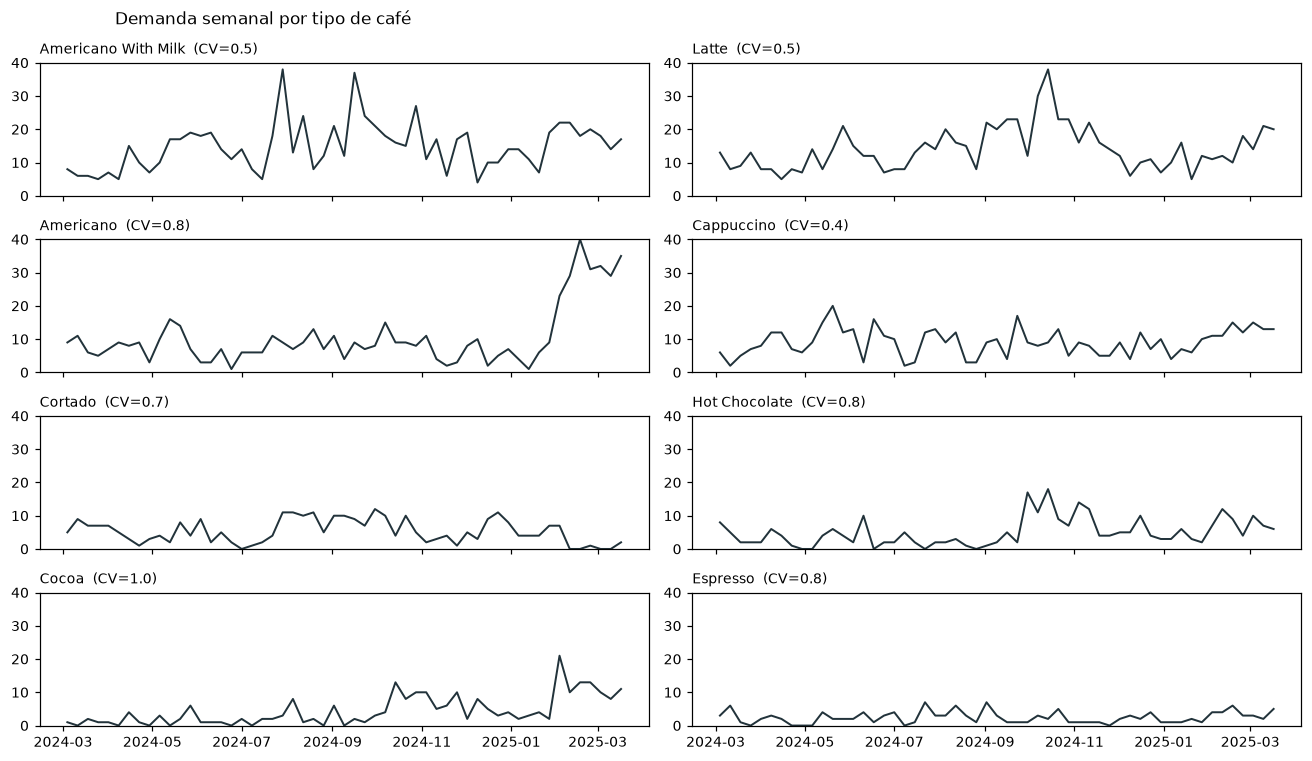

In [3]:
resumo = (semanal.groupby("coffee_name").qty
          .agg(["sum", "mean", "std"])
          .assign(cv=lambda d: (d["std"] / d["mean"]).round(2))
          .sort_values("sum", ascending=False)
          .round(1))
resumo.columns = ["total", "media_sem", "desvio", "cv"]
display(resumo)

fig, axes = plt.subplots(4, 2, figsize=(12, 7), sharex=True)
for ax, cafe in zip(axes.ravel(), resumo.index):
    h = semanal[semanal.coffee_name == cafe]
    ax.plot(h.week, h.qty, color=COR["real"], lw=1.3)
    ax.set_title(f"{cafe}  (CV={resumo.loc[cafe, 'cv']})", loc="left", fontsize=9)
    ax.set_ylim(0, 40)
fig.suptitle("Demanda semanal por tipo de café", x=.09, ha="left", fontsize=11)
fig.tight_layout(); plt.show()

---
## 4. Criação de Features

Tudo vem do próprio dado:

| Feature | Papel |
|---|---|
| `lag_1` | demanda da semana anterior |
| `lag_4` | demanda de 4 semanas atrás |
| `mm_4` | média das últimas 4 semanas |
| `tendencia` | `lag_1 - lag_4`, direção do último mês |

O modelo usa apenas `lag_1`, `mm_4` e `tendencia` como preditores.

Obs: Para predição usam-se apenas dados de semanas anteriores.

In [4]:
RANDOM_STATE    = 42
LAGS            = (1, 4)
ROLLS           = (4,)
MIN_TRAIN_WEEKS = 26
FEATURES        = ["lag_1", "mm_4", "tendencia"]
FORMULA_MISTA   = "delta ~ lag_1 + mm_4 + tendencia"

ET_PARAMS = dict(n_estimators=300, max_depth=6, min_samples_leaf=4,
                 max_features=0.8, random_state=RANDOM_STATE, n_jobs=-1)

def construir_features(df):
    p = df.sort_values(["coffee_name", "week"]).copy()
    q = p.groupby("coffee_name").qty

    for l in LAGS:
        p[f"lag_{l}"] = q.shift(l)
    p["mm_4"] = q.shift(1).rolling(4).mean()
    p["tendencia"] = p.lag_1 - p.lag_4

    return p.dropna(subset=FEATURES).reset_index(drop=True)


painel = construir_features(semanal)

print(f"{len(painel)} linhas modeláveis | {painel.week.nunique()} semanas")
display(painel.head())

408 linhas modeláveis | 51 semanas


,week,coffee_name,qty,lag_1,lag_4,mm_4,tendencia
0,2024-04-01,Americano,7,5.0,9.0,7.75,-4.0
1,2024-04-08,Americano,9,7.0,11.0,7.25,-4.0
2,2024-04-15,Americano,8,9.0,6.0,6.75,3.0
3,2024-04-22,Americano,9,8.0,5.0,7.25,3.0
4,2024-04-29,Americano,3,9.0,7.0,8.25,2.0


---
## 5. Modelo misto (LMM)

O modelo aprende coeficientes comuns a todos os cafés e
ao mesmo tempo permite que cada café tenha um ajuste próprio. 

Cafés com pouco histórico aproveitam o que foi aprendido com os de alto giro. Um modelo separado por café não consegue fazer isso.

Tecnicamente é um modelo linear misto, LMM (Tenho um artigo publicado na área de modelagem linear: https://www.sciencedirect.com/science/article/pii/S0305054825003661).

A validação é sequencial: para prever a semana seguinte, o modelo só enxerga semanas anteriores. Nunca há divisão aleatória dos dados, o que é essencial em séries temporais.

In [5]:
# Treina o modelo misto na variação (qty - lag_1)
def ajustar_misto(treino, janela_semanas=None, semana_alvo=None):
    warnings.simplefilter("ignore")
    if janela_semanas and semana_alvo:
        corte = pd.Timestamp(semana_alvo) - pd.Timedelta(weeks=janela_semanas)
        treino = treino[treino.week >= corte]

    tr = treino.assign(delta=treino.qty - treino.lag_1)
    return smf.mixedlm(FORMULA_MISTA, tr, groups=tr.coffee_name,
                           re_formula="~tendencia").fit(reml=False)



# Aplica o modelo treinado: efeito comum + ajuste por café, devolvido em unidades
def aplicar_misto(fit, teste):
    re = fit.random_effects
    pega = lambda c, k: float(re.get(c, pd.Series(dtype=float)).get(k, 0.))

    delta = (fit.predict(teste).values
             + teste.coffee_name.map(lambda c: pega(c, "Group")).values
             + teste.coffee_name.map(lambda c: pega(c, "tendencia")).values * teste.tendencia.values)
    
    return np.clip(delta + teste.lag_1.values, 0, None)


# Backtest walk-forward: treina até a semana W-1, prevê W, avança, repete
def backtest(painel, fn_prever, min_train=MIN_TRAIN_WEEKS):
    semanas = np.sort(painel.week.unique())
    saida = []
    for corte in semanas[min_train:]:
        tr = painel[painel.week < corte]
        te = painel[painel.week == corte].copy()
        te["pred"] = fn_prever(tr, te)
        saida.append(te)
    r = pd.concat(saida, ignore_index=True)
    r["erro"] = r.qty - r.pred
    r["ae"] = r.erro.abs()
    return r

bt = backtest(painel, lambda tr, te: aplicar_misto(ajustar_misto(tr), te))

---
## 6. Validação

Erra pouco? MAE, RMSE, WAPE e viés, no total e por tipo de café.

### 6.1 Métricas de validação

WAPE (erro absoluto total dividido pela demanda total) é a métrica principal. É aditiva entre
produtos e tem leitura direta para o negócio: "erramos X% do volume movimentado". 

In [6]:
def metricas(d):
    return pd.Series({
        "MAE":       d.ae.mean(),                      # erro médio em unidades
        "RMSE":      np.sqrt((d.erro ** 2).mean()),     # penaliza erros grandes
        "WAPE %":    100 * d.ae.sum() / d.qty.sum(),    # erro como % do volume total
        "Viés":      d.erro.mean(),                     # positivo = subestima
    })


print("Resultado global:"); display(metricas(bt).to_frame("Modelo misto").round(2))

print("Por tipo de café:")
display(bt.groupby("coffee_name").apply(metricas).sort_values("WAPE %").round(2))

Resultado global:


,Modelo misto
MAE,3.38
RMSE,4.84
WAPE %,35.61
Viés,0.52


Por tipo de café:


,MAE,RMSE,WAPE %,Viés
coffee_name,,,,
Cappuccino,2.49,2.96,27.02,0.04
Americano With Milk,4.31,5.54,27.86,-0.09
Latte,4.54,6.34,29.21,0.40
Americano,5.02,7.10,36.94,2.41
Cocoa,2.85,4.71,37.95,1.43
Hot Chocolate,3.76,4.80,49.01,0.93
Cortado,2.63,3.11,56.63,-0.70
Espresso,1.47,1.64,62.14,-0.30


### 6.2 Previsão contra realidade

Linha escura é o dado real, vermelha é o previsto.

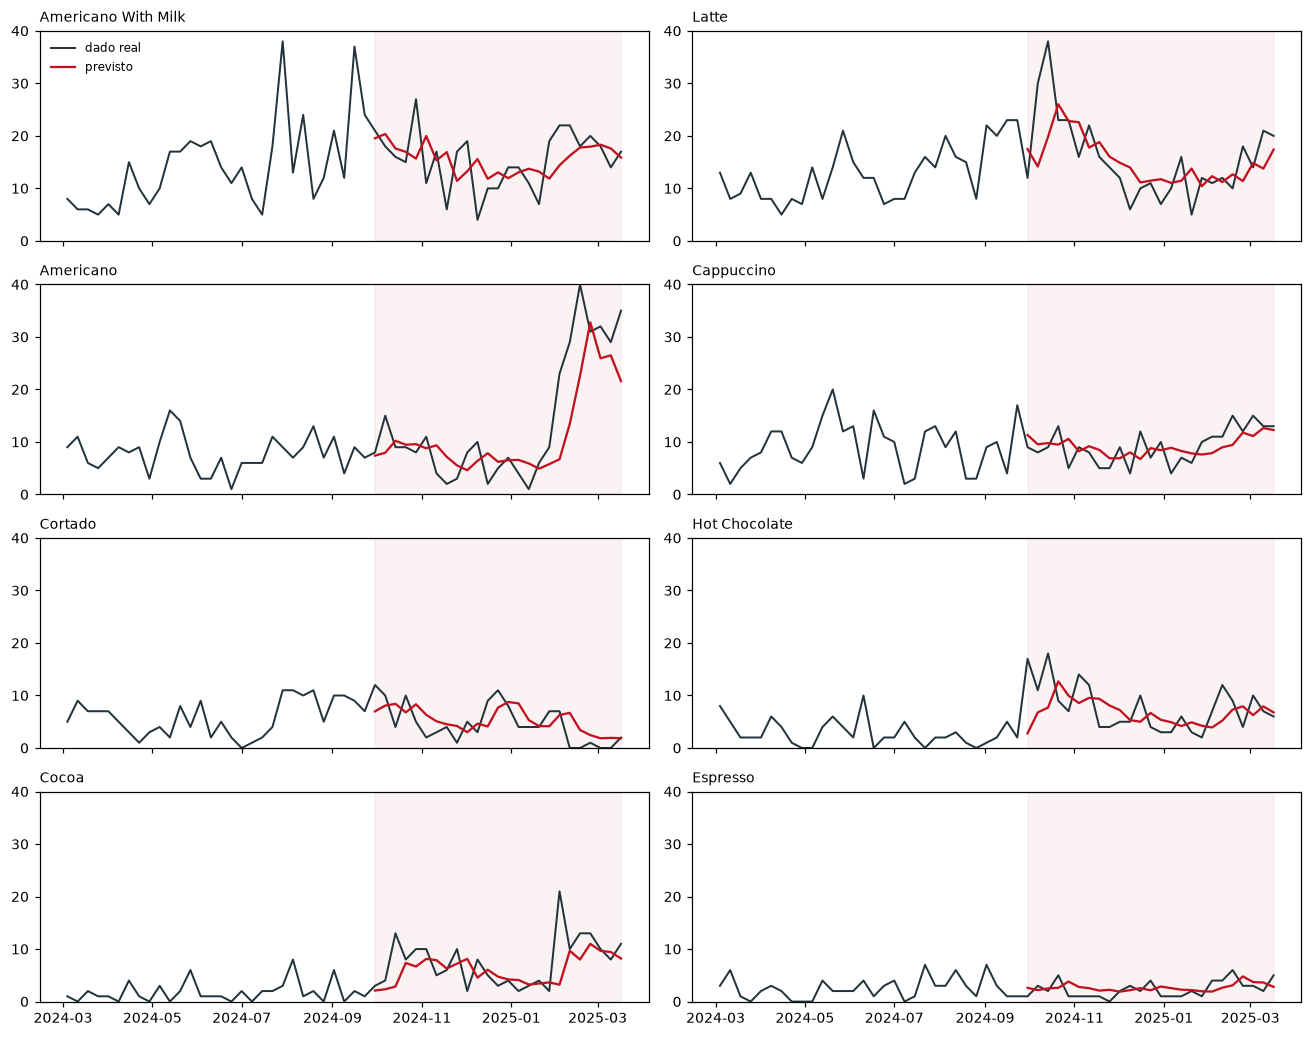

In [7]:
def plotar_series(semanal, bt=None, futuro=None):
    cafes = list(resumo.index)
    fig, axes = plt.subplots(len(cafes) // 2 + len(cafes) % 2, 2,
                             figsize=(12, 1.9 * (len(cafes) // 2 + 1)),
                             sharex=True, squeeze=False)

    for ax, cafe in zip(axes.ravel(), cafes):
        h = semanal.query("coffee_name == @cafe").sort_values("week")
        ax.plot(h.week, h.qty, color=COR["real"], lw=1.3, label="dado real")

        if bt is not None:
            b = bt.query("coffee_name == @cafe").sort_values("week")
            ax.plot(b.week, b.pred, color=COR["pred"], lw=1.5, label="previsto")
            ax.axvspan(b.week.min(), b.week.max(), color=COR["pred"], alpha=.05)

        if futuro is not None:
            f = futuro.query("coffee_name == @cafe").sort_values("semana_prevista")
            if len(f):
                ax.plot([h.week.iloc[-1]] + list(f.semana_prevista),
                        [h.qty.iloc[-1]] + list(f.qty_prevista),
                        "--o", color=COR["fut"], lw=1.6, ms=4, label="futuro")

        ax.set_title(cafe, loc="left", fontsize=9)
        ax.set_ylim(0, 40)
        

    for ax in axes.ravel()[len(cafes):]: ax.axis("off")
    axes.ravel()[0].legend(frameon=False, fontsize=8)
    fig.tight_layout(); plt.show()


plotar_series(semanal, bt)

---
## 7. Por que o modelo misto?

Cinco alternativas passaram pelo mesmo procedimento.

| Abordagem | O que faz | Onde falha |
|---|---|---|
| ExtraTrees individual | um modelo por café | pouca informação por modelo, variância alta |
| ExtraTrees global | um modelo para todos | ignora as diferenças entre cafés |
| Média móvel (4 sem) | média das últimas 4 semanas por café | não captura tendência |
| Prophet (Meta) | decomposição de tendência e sazonalidade por café | precisa de séries longas com sazonalidade clara |
| ARIMA(0,1,0) | repete a semana anterior | não aprende nada, piso de sanidade |


In [8]:
def _ajustar_et(hist, semana_alvo):
    m = ExtraTreesRegressor(**ET_PARAMS)
    m.fit(hist[FEATURES], hist.qty - hist.lag_1)
    return m


def prever_individual(treino, teste):
    """Um ExtraTrees por tipo de café: heterogeneidade total."""
    pred = pd.Series(index=teste.index, dtype=float)
    for cafe, bloco in teste.groupby("coffee_name"):
        m = _ajustar_et(treino[treino.coffee_name == cafe], bloco.week.iloc[0])
        pred.loc[bloco.index] = m.predict(bloco[FEATURES]) + bloco.lag_1.values
    return pred.clip(lower=0)


def prever_global(treino, teste):
    """Um único ExtraTrees para todos os cafés: homogeneidade total."""
    m = _ajustar_et(treino, teste.week.iloc[0])
    return np.clip(m.predict(teste[FEATURES]) + teste.lag_1.values, 0, None)


def prever_media_movel(treino, teste):
    """Média das últimas 4 semanas, por café."""
    pred = pd.Series(index=teste.index, dtype=float)
    for cafe, bloco in teste.groupby("coffee_name"):
        hist = treino[treino.coffee_name == cafe].sort_values("week").qty.values
        pred.loc[bloco.index] = hist[-4:].mean()
    return pred.clip(lower=0)

def prever_prophet(treino, teste):
    """Prophet por café."""
    pred = pd.Series(index=teste.index, dtype=float)
    for cafe, bloco in teste.groupby("coffee_name"):
        hist = treino[treino.coffee_name == cafe].sort_values("week")[["week", "qty"]]
        hist.columns = ["ds", "y"]
        m = Prophet(weekly_seasonality=False, daily_seasonality=False, yearly_seasonality=False)
        m.fit(hist)
        futuro = m.make_future_dataframe(periods=1, freq="W")
        prev = m.predict(futuro)
        pred.loc[bloco.index] = max(0, prev.yhat.iloc[-1])
    return pred.clip(lower=0)

abordagens = {
    "Misto (escolhido)":        bt,
    "ExtraTrees individual":    backtest(painel, prever_individual),
    "ExtraTrees global":        backtest(painel, prever_global),
    "Média móvel (4 sem)":      backtest(painel, prever_media_movel),
    "Naive / ARIMA(0,1,0)":             backtest(painel, lambda tr, te: te.lag_1),
    "Prophet":                  backtest(painel, prever_prophet),
}

comparativo = pd.DataFrame({k: metricas(v) for k, v in abordagens.items()}).T.round(2)
display(comparativo)

,MAE,RMSE,WAPE %,Viés
Misto (escolhido),3.38,4.84,35.61,0.52
ExtraTrees individual,3.61,5.04,37.96,0.23
ExtraTrees global,3.66,5.02,38.52,0.27
Média móvel (4 sem),3.61,5.13,37.94,0.27
"Naive / ARIMA(0,1,0)",3.82,5.29,40.24,0.14
Prophet,4.57,6.49,48.11,-0.37


---
## 8. Quanto vale prever melhor

Em nosso case consideraremos que o erro encontrado é falta de café (ruptura).


Diferença nos lucros ao usar o modelo proposto (por semana):


coffee_name
Americano             -14.18
Americano With Milk    26.00
Cappuccino             28.59
Cocoa                  35.22
Cortado                 1.35
Espresso               -2.24
Hot Chocolate          14.28
Latte                  39.03
Name: valor recuperado (u.m.), dtype: float64


6,659 u.m./ano por máquina
199,757,111 u.m./ano em 30,000 máquinas


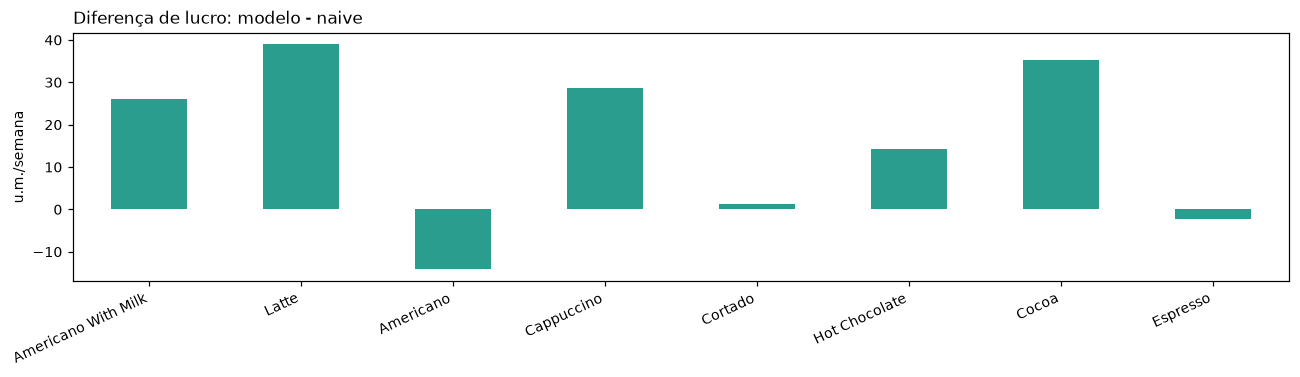

In [9]:
bt_naive = backtest(painel, lambda tr, te: te.lag_1)
ticket_cafe = bruto.groupby("coffee_name").money.mean()

# Erro evitado por café (un/semana) × preço médio = valor recuperado
erro_modelo = bt.groupby("coffee_name").ae.mean()
erro_naive  = bt_naive.groupby("coffee_name").ae.mean()
ganho = (erro_naive - erro_modelo) * ticket_cafe

print("Diferença nos lucros ao usar o modelo proposto (por semana):")
display(ganho.round(2).rename("valor recuperado (u.m.)"))

ganho_maq_ano = ganho.sum() * 52
FROTA = 30_000
print(f"\n{ganho_maq_ano:,.0f} u.m./ano por máquina")
print(f"{ganho_maq_ano * FROTA:,.0f} u.m./ano em {FROTA:,} máquinas")

# Gráfico
ganho.loc[resumo.index].plot(kind="bar", figsize=(12, 3.5), color=COR["fut"])
plt.ylabel("u.m./semana"); plt.xlabel("")
plt.title("Diferença de lucro: modelo - naive", loc="left")
plt.xticks(rotation=25, ha="right"); plt.tight_layout(); plt.show()

Essa é uma estimativa teórica: assume que toda unidade de erro gera custo.

---
## 9. Função de produção

```python
prever_demanda(n_semanas=1)
```

- `n_semanas`: horizonte, padrão 1 e é a recomendação. Acima de 1 a previsão de um passo vira
  insumo do seguinte e o erro se acumula.

A saída traz a previsão e a quantidade sugerida de reposição, com margem para cobrir 95% dos cenários de demanda (intervalo de confiança).

In [10]:
SIGMA = bt.groupby("coffee_name").erro.std().to_dict()
Z_SERVICO = 1.645


def prever_demanda(n_semanas=1):
    sem = semanal.copy()
    fit = ajustar_misto(construir_features(sem))

    saida = []
    for h in range(1, n_semanas + 1):
        prox = sem.week.max() + pd.Timedelta(days=7)
        sem["qty"] = sem.qty.astype(float)
        sem = pd.concat([sem, sem[sem.week == sem.week.max()]
                 .assign(week=prox, qty=np.nan)], ignore_index=True)

        alvo = construir_features(sem)
        alvo = alvo[alvo.week == prox].copy()
        alvo["pred"] = aplicar_misto(fit, alvo)

        sem.loc[sem.week == prox, "qty"] = alvo.pred.values
        saida.append(alvo.assign(horizonte=h, semana_prevista=prox))

    r = pd.concat(saida, ignore_index=True)
    sig = r.coffee_name.map(SIGMA) * np.sqrt(r.horizonte)
    r["qty_prevista"]     = r.pred.round().astype(int)
    r["estoque_sugerido"] = np.ceil(r.pred + Z_SERVICO * sig).astype(int)

    return (r[["semana_prevista", "coffee_name", "horizonte",
               "qty_prevista", "estoque_sugerido"]]
            .sort_values(["horizonte", "qty_prevista"], ascending=[True, False])
            .reset_index(drop=True))

### 9.1 Uso padrão: todos os cafés, próxima semana

,semana_prevista,coffee_name,horizonte,qty_prevista,estoque_sugerido
0,2025-03-24,Americano,1,29,40
1,2025-03-24,Latte,1,18,29
2,2025-03-24,Americano With Milk,1,16,26
3,2025-03-24,Cappuccino,1,12,18
4,2025-03-24,Cocoa,1,10,18
5,2025-03-24,Hot Chocolate,1,7,15
6,2025-03-24,Espresso,1,4,7
7,2025-03-24,Cortado,1,2,8


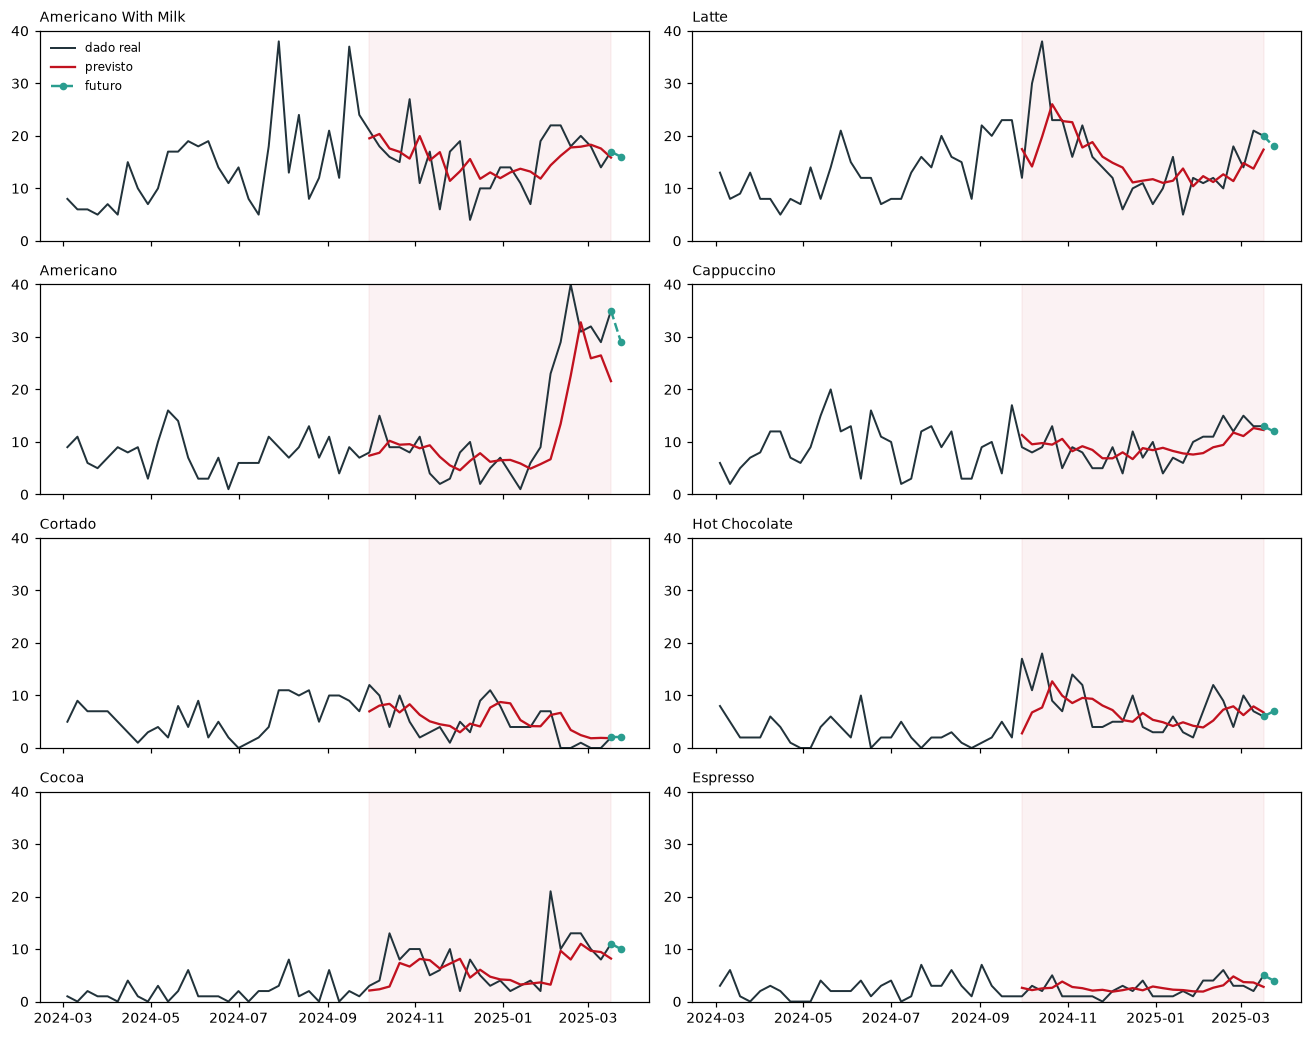

In [11]:
previsao = prever_demanda(n_semanas=1)
display(previsao)

plotar_series(semanal, bt, futuro=previsao)